# Week 6
# Understanding the Alogrithms


Goal: We want the Euler Characteristic Curve(ECC) for a filtered complex:

Each cell(simplex) contributes either a +1 or -1 depending on the dimension

This contribution appears exactly at the filtration level 
𝑓(𝜎)
f(σ) where the cell enters.

Setup for Vr-complex:
we are given a finite collection of Points X(point cloud) and also the parameter Episilon. Our Vr-Complex that can be constructed from X is the collection of all subset of the diameter 2 * Epsilons. we only care about simplices whose vertices are within distance 2ϵ, the filtration of each simplex will be determined by its diamater
The Vietoris–Rips complex is a flag complex; this means that a subset S of vertices is in the complex if every pair of vertices in S is in the complex. This is a key idea as this is saying that If every pair of vertices in a set 𝑆 is connected by an edge, then the whole set 𝑆 automatically forms a simplex. Once you know which vertices are connected pairwise, you know all higher-dimensional simplices automatically.


# Algo 1 COMPUTE LOCAL CONTRIBUTIONS V-R


**Goal:** Compute the Euler characteristic curve (ECC) of a Vietoris–Rips complex efficiently by generating each simplex exactly once and storing its contribution at the filtration value.

---

## Inputs

- `X = [x1, x2, ..., xn]`: ordered point cloud in ℝᵈ  
- `epsilon`: maximum filtration value (distance threshold)

---

## Key Idea

- Vietoris–Rips complex is a **flag complex**:
  - A set of vertices `S` is a simplex if **every pair** of vertices in `S` is connected by an edge.
  - The entire complex is determined by its **1-skeleton graph** (vertices + edges).  
  - Listing all simplices is equivalent to listing all **cliques** in the 1-skeleton.

---

## Steps (Algorithm 1)

1. **Construct local graphs**:  
   For each point `xi`, define its local graph `Gi` as:  
   `Gi = { xj in X : j > i and distance(xi, xj) <= epsilon }`  
   → Ensures each simplex is generated exactly once using `xi` as the smallest vertex.

2. **Generate simplices**:  
   - 0-simplices (vertices): contribution = +1  
   - 1-simplices (edges): for each neighbor xj in Gi, contribution = -1, filtration = distance(xi, xj)

3. **Store contributions**:  
   Each simplex σ contributes a tuple: `(filtration(σ), (-1)^dim(σ))`

4. **Sort by filtration**:  
   Sort contributions to reconstruct the ECC via cumulative sum.


In [2]:
import numpy as np

# Example point cloud
X = np.array([[0,0], [1,0], [2,0], [1,1], [2,1], [3,0]])
epsilon = 1.5

# Step 1: Build local graphs
def local_graphs(X, epsilon):
    n = len(X)
    G = [[] for _ in range(n)]
    for i in range(n):
        for j in range(i+1, n):
            if np.linalg.norm(X[i] - X[j]) <= epsilon:
                G[i].append(j)
    return G

G = local_graphs(X, epsilon)
print("Local graphs for each point:")
for i, neighbors in enumerate(G):
    print(f"x{i}: {neighbors}")

# Step 2: Generate simplices (0- and 1-simplices) with labels
contributions = []

# 0-simplices (vertices)
print("\n0-simplices (vertices) and their contributions:")
for i in range(len(X)):
    contributions.append((0, +1))
    print(f"x{i}: contribution +1 at filtration 0")

# 1-simplices (edges)
print("\n1-simplices (edges) and their contributions:")
for i, neighbors in enumerate(G):
    for j in neighbors:
        dist = np.linalg.norm(X[i] - X[j])
        contributions.append((dist, -1))
        print(f"[x{i}, x{j}]: contribution -1 at filtration {dist:.3f}")

# Step 3: Sort by filtration
contributions.sort(key=lambda x: x[0])
print("\nContributions sorted by filtration:")
for f, val in contributions:
    print(f"Filtration {f:.3f}, contribution {val}")

# Step 4: Compute ECC by cumulative sum
filtrations, vals = zip(*contributions)
ecc = np.cumsum(vals)
print("\nEuler Characteristic Curve (ECC):")
for f, e in zip(filtrations, ecc):
    print(f"Filtration {f:.3f}: ECC = {e}")


Local graphs for each point:
x0: [1, 3]
x1: [2, 3, 4]
x2: [3, 4, 5]
x3: [4]
x4: [5]
x5: []

0-simplices (vertices) and their contributions:
x0: contribution +1 at filtration 0
x1: contribution +1 at filtration 0
x2: contribution +1 at filtration 0
x3: contribution +1 at filtration 0
x4: contribution +1 at filtration 0
x5: contribution +1 at filtration 0

1-simplices (edges) and their contributions:
[x0, x1]: contribution -1 at filtration 1.000
[x0, x3]: contribution -1 at filtration 1.414
[x1, x2]: contribution -1 at filtration 1.000
[x1, x3]: contribution -1 at filtration 1.000
[x1, x4]: contribution -1 at filtration 1.414
[x2, x3]: contribution -1 at filtration 1.414
[x2, x4]: contribution -1 at filtration 1.000
[x2, x5]: contribution -1 at filtration 1.000
[x3, x4]: contribution -1 at filtration 1.000
[x4, x5]: contribution -1 at filtration 1.414

Contributions sorted by filtration:
Filtration 0.000, contribution 1
Filtration 0.000, contribution 1
Filtration 0.000, contribution 1
Fi

# Algo 2: Increasing Dimension
By using the outputs from Algo 1 we are able to up the dimension(create new simplicies from these local graphs)
Goal: Extend simplices generated from Algorithm 1 to higher dimensions in the Vietoris–Rips complex and compute their contributions to the Euler characteristic curve (ECC).

$$
\textbf{Algorithm 2: Increase Dimension for Vietoris–Rips Complex}
$$

Let $\sigma = [v_0, v_1, \dots, v_d]$ be a $d$-simplex generated by Algorithm 1, and let $G_{v_i}$ be the local graph of vertex $v_i$ (all neighbors with index $j > i$).  

**Step 1: Find common neighbors**  
$$
\text{common\_neighbors} = \bigcap_{i=0}^{d} G_{v_i}
$$

**Step 2: Extend simplex**  
For each $v_\text{new} \in \text{common\_neighbors}$, create a new $(d+1)$-simplex
$$
\sigma' = \sigma \cup \{ v_\text{new} \}
$$
Update the filtration value as the largest edge in the simplex:
$$
f(\sigma') = \max\Big(f(\sigma), \max_{v_i \in \sigma} \text{dist}(v_i, v_\text{new}) \Big)
$$
The contribution to the Euler characteristic curve is
$$
\text{contribution}(\sigma') = \big(f(\sigma'), (-1)^{d+1}\big)
$$

**Step 3: Recursion**  
Apply the same procedure to $\sigma'$ until no more extensions are possible (i.e., $\text{common\_neighbors} = \emptyset$).  

**Step 4: Repeat for all simplices from Algorithm 1**  
$$
0\text{-simplices (vertices)}, \quad
1\text{-simplices (edges)}, \quad
\dots
$$
- Each simplex is extended only along its common neighbors to prevent duplicates.  
- The filtration value is always the **largest edge** in the simplex.  
- Contributions are stored as $(f(\sigma), (-1)^{\dim(\sigma)})$ to build the Euler characteristic curve.  


In [5]:
def increase_dimension(simplex, common_neighbors, distances, list_of_contributions):
    """
    Recursively generates all higher-dimensional simplices containing the given simplex.

    Parameters
    ----------
    simplex : list[int]
        Current simplex as a list of vertex indices, ordered.
    common_neighbors : set[int]
        Set of vertices that can extend the current simplex (common neighbors of all vertices in simplex)
    distances : dict[tuple[int,int], float]
        Precomputed pairwise distances between vertices.
    list_of_contributions : list[tuple[float, int]]
        Stores the (filtration value, EC contribution) for each simplex.
    """

    # Current filtration value is the maximum edge length in the simplex
    if len(simplex) == 1:
        current_filtration = 0  # vertices contribute at 0
    else:
        edges = [(simplex[i], simplex[j]) for i in range(len(simplex)) for j in range(i+1, len(simplex))]
        current_filtration = max(distances[(min(u,v), max(u,v))] for u,v in edges)

    # Add current simplex contribution to the list
    list_of_contributions.append((current_filtration, (-1) ** (len(simplex)-1)))

    # Try to extend the simplex by adding one neighbor at a time
    for v_new in sorted(common_neighbors):
        # New simplex
        new_simplex = simplex + [v_new]

        # Compute new filtration: max(current simplex, edges to new vertex)
        max_edge = max(distances[(min(v, v_new), max(v, v_new))] for v in simplex)
        new_filtration = max(current_filtration, max_edge)

        # Update common neighbors for the new simplex
        new_common_neighbors = common_neighbors.intersection(set(neighbors[v_new]))

        # Recurse
        increase_dimension(new_simplex, new_common_neighbors, distances, list_of_contributions)


Local graphs:
x0: [1, 2]
x1: []
x2: []
x3: []
x4: []
x5: []
x6: []

Filtration  |  Contribution  |  ECC
   0.000 |            1 | 1
   0.000 |            1 | 2
   0.000 |            1 | 3
   0.000 |            1 | 4
   0.000 |            1 | 5
   0.000 |            1 | 6
   0.000 |            1 | 7
   1.000 |           -1 | 6
   1.000 |           -1 | 5


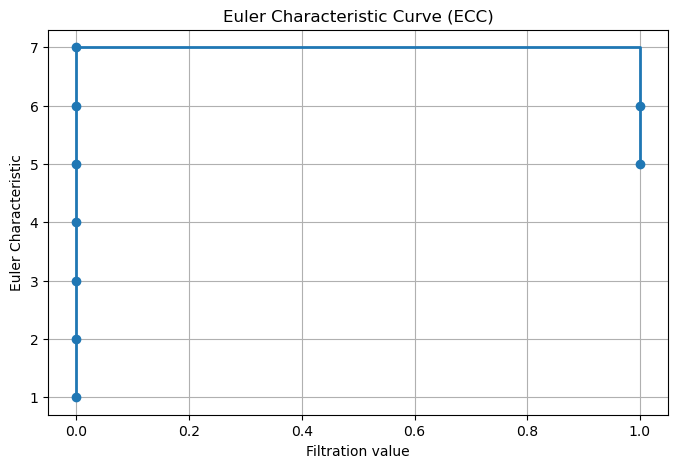

In [7]:
#Algo 1 + Algo 2 in action
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# Example point cloud
# ------------------------
X = np.array([
    [0, 0],  # x0
    [1, 0],  # x1
    [0, 1],  # x2
    [1, 2],  # x3
    [2, 1],  # x4
    [4, 1],  # x5
    [3, 2],  # x6
])

epsilon = 0.5

# ------------------------
# Step 1: Build local graphs (Algorithm 1)
# ------------------------
def local_graphs(X, epsilon):
    n = len(X)
    G = [[] for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(X[i] - X[j]) <= epsilon:
                G[i].append(j)

    return G

G = local_graphs(X, epsilon)
print("Local graphs:")
for i, neighbors in enumerate(G):
    print(f"x{i}: {neighbors}")

# ------------------------
# Step 2: Precompute pairwise distances
# ------------------------
n = len(X)
distances = {}

for i in range(n):
    for j in range(i + 1, n):
        distances[(i, j)] = np.linalg.norm(X[i] - X[j])

# ------------------------
# Step 3: Algorithm 2 - Increase Dimension
# ------------------------
# Stores (filtration value, Euler characteristic contribution)
list_of_contributions = []

def increase_dimension(simplex, common_neighbors, current_filtration):
    """
    Recursively generates all simplices containing 'simplex'
    and records their contributions to the ECC.
    """

    # Add contribution of the current simplex
    dimension = len(simplex) - 1
    contribution = (-1) ** dimension
    list_of_contributions.append((current_filtration, contribution))

    # Try to extend the simplex
    for v_new in sorted(common_neighbors):
        # Compute filtration value for the new simplex
        max_edge = max(
            distances[(min(v, v_new), max(v, v_new))] for v in simplex
        )
        new_filtration = max(current_filtration, max_edge)

        # Update common neighbors
        new_common_neighbors = common_neighbors.intersection(set(G[v_new]))

        # Recurse
        increase_dimension(
            simplex + [v_new],
            new_common_neighbors,
            new_filtration
        )

# ------------------------
# Step 4: Run Algorithm 1 + 2
# ------------------------
for i in range(n):
    # Each vertex starts as a 0-simplex
    increase_dimension([i], set(G[i]), 0)

# ------------------------
# Step 5: Sort contributions and compute ECC
# ------------------------
list_of_contributions.sort(key=lambda x: x[0])

filtrations, values = zip(*list_of_contributions)
ecc = np.cumsum(values)

print("\nFiltration  |  Contribution  |  ECC")
for f, v, e in zip(filtrations, values, ecc):
    print(f"{f:8.3f} | {v:12} | {e}")

# ------------------------
# Step 6: Plot ECC
# ------------------------
plt.figure(figsize=(8, 5))
plt.step(filtrations, ecc, where="post", linewidth=2)
plt.scatter(filtrations, ecc, zorder=5)
plt.xlabel("Filtration value")
plt.ylabel("Euler Characteristic")
plt.title("Euler Characteristic Curve (ECC)")
plt.grid(True)
plt.show()


[0 0 0 0 0 0 0 0 0 0]
[0 1 2 3 4 5 6 7 8 9]
Local graphs:
x0: []
x1: []
x2: []
x3: []
x4: []
x5: []
x6: []
x7: []
x8: []
x9: []

Filtration  |  Contribution  |  ECC
   0.000 |            1 | 1
   0.000 |            1 | 2
   0.000 |            1 | 3
   0.000 |            1 | 4
   0.000 |            1 | 5
   0.000 |            1 | 6
   0.000 |            1 | 7
   0.000 |            1 | 8
   0.000 |            1 | 9
   0.000 |            1 | 10


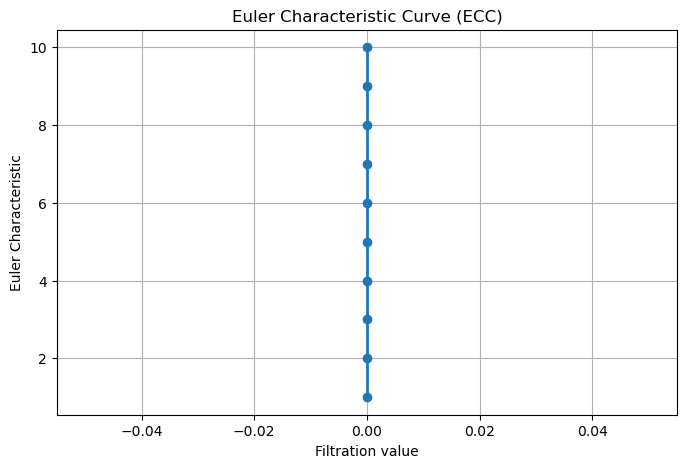

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Setup: Generate 50 random points in 2D
#np.random.seed(42)  # for reproducibility
X = np.random.rand(10, 2) * 10  # scale to [0,10]x[0,10]
epsilon =1.3

# ------------------------
# Step 0: Ordering of verticies by epsilon-neighbors
# ------------------------
# first compute the epsilon neighbor counts
def epsilon_degrees(X, epsilon):
    n = len(X)
    degrees = np.zeros(n, dtype=int)

    for i in range(n):
        for j in range(n):
            if i != j and np.linalg.norm(X[i] - X[j]) <= epsilon:
                degrees[i] += 1

    return degrees
#Reorder our verticies
degrees = epsilon_degrees(X, epsilon)
print(degrees)
order = np.argsort(degrees)          # increasing ε-degree
X = X[order]    
print(order)

# ------------------------
# Step 1: Build local graphs (Algorithm 1)
# ------------------------
def local_graphs(X, epsilon):
    n = len(X)
    G = [[] for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(X[i] - X[j]) <= epsilon:
                G[i].append(j)

    return G

G = local_graphs(X, epsilon)
print("Local graphs:")
for i, neighbors in enumerate(G):
    print(f"x{i}: {neighbors}")

# ------------------------
# Step 2: Precompute pairwise distances
# ------------------------
n = len(X)
distances = {}

for i in range(n):
    for j in range(i + 1, n):
        distances[(i, j)] = np.linalg.norm(X[i] - X[j])

# ------------------------
# Step 3: Algorithm 2 - Increase Dimension
# ------------------------
# Stores (filtration value, Euler characteristic contribution)
list_of_contributions = []

def increase_dimension(simplex, common_neighbors, current_filtration):
    """
    Recursively generates all simplices containing 'simplex'
    and records their contributions to the ECC.
    """

    # Add contribution of the current simplex
    dimension = len(simplex) - 1
    contribution = (-1) ** dimension
    list_of_contributions.append((current_filtration, contribution))

    # Try to extend the simplex
    for v_new in sorted(common_neighbors):
        # Compute filtration value for the new simplex
        max_edge = max(
            distances[(min(v, v_new), max(v, v_new))] for v in simplex
        )
        new_filtration = max(current_filtration, max_edge)

        # Update common neighbors
        new_common_neighbors = common_neighbors.intersection(set(G[v_new]))

        # Recurse
        increase_dimension(
            simplex + [v_new],
            new_common_neighbors,
            new_filtration
        )

# ------------------------
# Step 4: Run Algorithm 1 + 2
# ------------------------
for i in range(n):
    # Each vertex starts as a 0-simplex
    increase_dimension([i], set(G[i]), 0)

# ------------------------
# Step 5: Sort contributions and compute ECC
# ------------------------
list_of_contributions.sort(key=lambda x: x[0])

filtrations, values = zip(*list_of_contributions)
ecc = np.cumsum(values)

print("\nFiltration  |  Contribution  |  ECC")
for f, v, e in zip(filtrations, values, ecc):
    print(f"{f:8.3f} | {v:12} | {e}")

# ------------------------
# Step 6: Plot ECC
# ------------------------
plt.figure(figsize=(8, 5))
plt.step(filtrations, ecc, where="post", linewidth=2)
plt.scatter(filtrations, ecc, zorder=5)
plt.xlabel("Filtration value")
plt.ylabel("Euler Characteristic")
plt.title("Euler Characteristic Curve (ECC)")
plt.grid(True)
plt.show()


# Questions on Algorithms 1 + 2

## 1) How do we know the algorithm does not overcount simplices?

- Each vertex $x_i$ only considers **subsequent neighbors** $x_j$ with $j > i$.
- A simplex $[x_i, x_j, x_k, \dots]$ is generated **exactly once**, when the **smallest vertex** in the simplex is processed.
- Algorithm 2 extends simplices dimension by dimension using **common neighbors** that come after all current vertices.
- Therefore, every simplex contributes **exactly once** to the Euler characteristic curve.

## 2) What is parallelized?

- Each vertex $x_i$ has its own **local graph** $G_i$.
- Generating all simplices that contain $x_i$ (Algorithms 1 + 2) can be done **independently of other vertices**.
- Steps that can be run in parallel:
  1. Building local graphs for each vertex.
  2. Generating simplices from each local graph.
- The **unit of parallel work** is all simplices generated from a single vertex's local graph.

## 3) What happens when not all points are neighbors?

- Local graphs $G_i$ are smaller, since some points are beyond $\epsilon$.
- Implications:
  1. Some edges (1-simplices) and higher-dimensional simplices do not exist.
  2. The Euler characteristic curve still works; it reflects the actual connectivity of the point cloud.
  3. Sparse point clouds may lead to **higher ECC at start** and **slower drops**, because fewer simplices appear.
- The algorithm is robust — it naturally adapts to sparse or disconnected data.


# Choice of vertex ordering
It is important to note that the total running time  of Algorithm 1 can be dominated by a few verticies whose simplex tree is a lot bigger than the others. We can circumvent this by choosing a different order for a verticies. One efficient choice is to order the vertices by increasing number of ϵ-neighbors. Since the local graph for each vertex is constructed by considering only its subsequent neighbors, this ordering will produce more evenly sized simplex trees


# Conducting experiment 
How ECC chnages based on different distributions

In [72]:
import numpy as np
from itertools import combinations
#distance matrix
def pairwise_distances(X):
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = np.linalg.norm(X[i] - X[j])
            D[i, j] = D[j, i] = d
    return D


In [74]:
def euler_characteristic(X, epsilon):
    n = len(X)
    D = pairwise_distances(X)

    # 0-simplices
    V = n

    # 1-simplices (edges)
    edges = [(i, j) for i in range(n) for j in range(i+1, n)
             if D[i, j] <= epsilon]
    E = len(edges)

    # 2-simplices (triangles)
    T = 0
    for i, j, k in combinations(range(n), 3):
        if (D[i, j] <= epsilon and
            D[i, k] <= epsilon and
            D[j, k] <= epsilon):
            T += 1

    # Euler characteristic
    chi = V - E + T
    return chi


In [76]:
#sampling dist
def sample_uniform(n):
    return np.random.rand(n, 2)

def sample_beta(n, a=2, b=5):
    return np.column_stack((
        np.random.beta(a, b, n),
        np.random.beta(a, b, n)
    ))


In [86]:
def run_simulation(sample_fn, epsilons, n=40, N=200):
    results = {eps: [] for eps in epsilons}

    for eps in epsilons:
        for _ in range(N):
            X = sample_fn(n)
            chi = euler_characteristic(X, eps)
            results[eps].append(chi)

    return results
epsilons = [0.25, 0.5, 0.75]
N = 300
n = 40

uniform_results = run_simulation(sample_uniform, epsilons, n, N)
beta_results = run_simulation(sample_beta, epsilons, n, N)

#plotting 
import matplotlib.pyplot as plt

def plot_histograms(results, title):
    plt.figure(figsize=(10, 4))
    for eps, values in results.items():
        plt.hist(values, bins=20, alpha=0.5, label=f"ε = {eps}")
    plt.xlabel("Euler Characteristic")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.show()



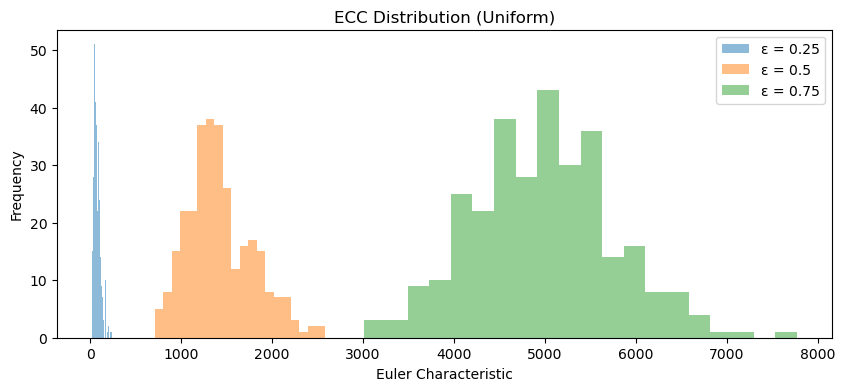

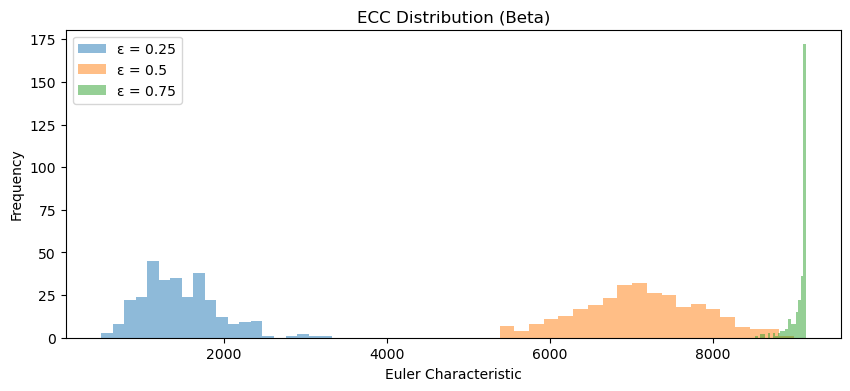

In [87]:
plot_histograms(uniform_results, "ECC Distribution (Uniform)")
plot_histograms(beta_results, "ECC Distribution (Beta)")


Local graphs:
x0: []
x1: [4]
x2: [3]
x3: []
x4: []
x5: [8, 9]
x6: [7, 9]
x7: [8, 9]
x8: [9]
x9: []

Filtration  |  Contribution  |  ECC
   0.000 |            1 | 1
   0.000 |            1 | 2
   0.000 |            1 | 3
   0.000 |            1 | 4
   0.000 |            1 | 5
   0.000 |            1 | 6
   0.000 |            1 | 7
   0.000 |            1 | 8
   0.000 |            1 | 9
   0.000 |            1 | 10
   0.366 |           -1 | 9
   0.460 |           -1 | 8
   0.461 |           -1 | 7
   0.583 |           -1 | 6
   0.597 |           -1 | 5
   0.608 |           -1 | 4
   0.669 |            1 | 5
   0.669 |           -1 | 4
   0.934 |            1 | 5
   0.934 |           -1 | 4
   0.997 |           -1 | 3
   0.997 |            1 | 4


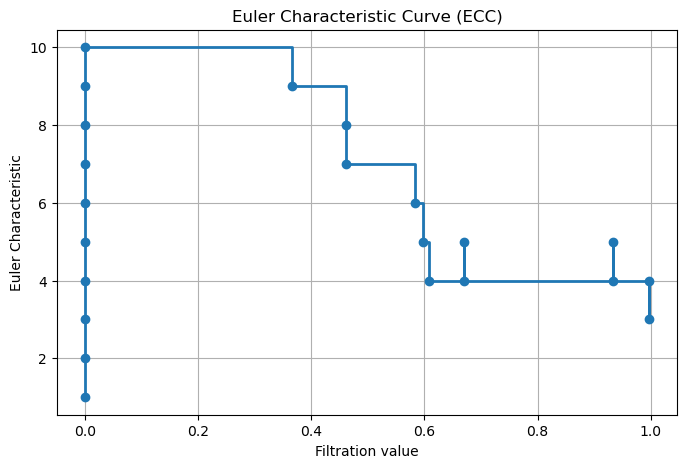

[4 1 2 1 3 0 2 1 3 1]
[5 1 7 3 9 6 2 4 8 0]


In [23]:
def sample_sphere(n):
    """Uniformly sample n points on a sphere"""
    #generates n random numbers uniformly in the range [0,1].
    #u and v are two sets of random numbers we will use to calculate angles.
    #We use two independent random numbers because a point on a sphere is determined by two angles (theta and phi).
    u = np.random.rand(n)
    v = np.random.rand(n)
    theta = 2 * np.pi * u
    phi = np.arccos(1 - 2*v)
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    return np.column_stack([x, y, z])
    
n_points = 10
epsilon =1

X= sample_sphere(n_points)
# ------------------------
# Step 0: Ordering of verticies by epsilon-neighbors
# ------------------------
# first compute the epsilon neighbor counts
def epsilon_degrees(X, epsilon):
    n = len(X)
    degrees = np.zeros(n, dtype=int)

    for i in range(n):
        for j in range(n):
            if i != j and np.linalg.norm(X[i] - X[j]) <= epsilon:
                degrees[i] += 1

    return degrees
#Reorder our verticies
degrees = epsilon_degrees(X, epsilon)

order = np.argsort(degrees)          # increasing ε-degree
X = X[order]    


# ------------------------
# Step 1: Build local graphs (Algorithm 1)
# ------------------------
def local_graphs(X, epsilon):
    n = len(X)
    G = [[] for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(X[i] - X[j]) <= epsilon:
                G[i].append(j)

    return G

G = local_graphs(X, epsilon)
print("Local graphs:")
for i, neighbors in enumerate(G):
    print(f"x{i}: {neighbors}")

# ------------------------
# Step 2: Precompute pairwise distances
# ------------------------
n = len(X)
distances = {}

for i in range(n):
    for j in range(i + 1, n):
        distances[(i, j)] = np.linalg.norm(X[i] - X[j])

# ------------------------
# Step 3: Algorithm 2 - Increase Dimension
# ------------------------
# Stores (filtration value, Euler characteristic contribution)
list_of_contributions = []

def increase_dimension(simplex, common_neighbors, current_filtration):
    """
    Recursively generates all simplices containing 'simplex'
    and records their contributions to the ECC.
    """

    # Add contribution of the current simplex
    dimension = len(simplex) - 1
    contribution = (-1) ** dimension
    list_of_contributions.append((current_filtration, contribution))

    # Try to extend the simplex
    for v_new in sorted(common_neighbors):
        # Compute filtration value for the new simplex
        max_edge = max(
            distances[(min(v, v_new), max(v, v_new))] for v in simplex
        )
        new_filtration = max(current_filtration, max_edge)

        # Update common neighbors
        new_common_neighbors = common_neighbors.intersection(set(G[v_new]))

        # Recurse
        increase_dimension(
            simplex + [v_new],
            new_common_neighbors,
            new_filtration
        )
# ------------------------
# Step 4: Run Algorithm 1 + 2
# ------------------------
for i in range(n):
    # Each vertex starts as a 0-simplex
    increase_dimension([i], set(G[i]), 0)

# ------------------------
# Step 5: Sort contributions and compute ECC
# ------------------------
list_of_contributions.sort(key=lambda x: x[0])

filtrations, values = zip(*list_of_contributions)
ecc = np.cumsum(values)

print("\nFiltration  |  Contribution  |  ECC")
for f, v, e in zip(filtrations, values, ecc):
    print(f"{f:8.3f} | {v:12} | {e}")

# ------------------------
# Step 6: Plot ECC
# ------------------------
plt.figure(figsize=(8, 5))
plt.step(filtrations, ecc, where="post", linewidth=2)
plt.scatter(filtrations, ecc, zorder=5)
plt.xlabel("Filtration value")
plt.ylabel("Euler Characteristic")
plt.title("Euler Characteristic Curve (ECC)")
plt.grid(True)
plt.show()

print(degrees)
print(order)